# Theta Forecaster

This notebook demonstrates the **Theta** forecasting method using the `aeon` toolkit.
 The Theta algorithm is a simple and fast forecaster that is surprisingly effective.
 It was proposed in 2000 in this paper:

Assimakopoulos, V., & Nikolopoulos, K. (2000). The Theta model: a decomposition
approach to forecasting International Journal of Forecasting, 16(4), 521–530.
https://doi.org/10.1016/S0169-2070(00)00066-2

It was the overall winner in the M3 forecasting competition across all 3,003
series, outperforming other statistical models like ARIMA, exponential smoothing, and more
complex approaches. It was particularly strong on yearly and quarterly data, and it became widely cited as a benchmark thereafter.

In the M4 Competition (2018) Theta was still competitive, but pure Theta was outperformed by hybrid and ensemble methods like Theta+ETS+ARIMA combinations, and machine learning–enhanced versions. The best-performing entries in M4 (e.g., Hybrid ES-RNN and Theta combinations) included Theta as a component in an ensemble rather than using it alone.

Makridakis et al. (2020), The M4 Competition: Results, findings, conclusion and way forward, International Journal of Forecasting, 36(1), 54–74.

*The classical Theta method shown here is the foundation of the [Dynamic Optimised Theta Model (DOTM)](dotm.ipynb), which optimises the theta parameter, updates the trend line dynamically, and adds seasonal handling.*


## 1. How the Theta algorithm works

The classical Theta method forecasts a univariate time series $y$ by four steps that
combine a linear trend and a smoothed series describing variation around the trend.


1. **Fit a linear trend** of $y$ against time estimated by ordinary least squares (the
“θ=0 line”).
$$\hat{y}^{\text{trend}}_t = a + bt$$
2. **Form the theta line**, which combines the original series with the linear
trend:

$$ \tilde{y}_t(\theta) = \theta\, y_t + (1-\theta)\, \hat{y}^{\text{trend}}_t,$$

3. **Smooth the theta line** using a simple exponential smoothing (SES) with
smoothing parameter $\alpha$ to obtain the **level**:

$$
\ell_t = \alpha\, \tilde{y}_t + (1 - \alpha)\, \ell_{t-1}
$$
4. **Combine the level and trend** to form the forecast, using a weight parameter $w$:

$$
\hat{y}_{t+1} = (1 - w)\, \ell_t + w\, \hat{y}^{\text{trend}}_t
$$
The standard default parameter value is $\theta=2$ and $\alpha$ is found through grid
 search on range $(0,1]$ to find the value with the lowest sum of squared errors (SSE)
  on the train data.


  <img src="../img/theta.png" width="600" alt="Theta forecasting algorithm">


## 2. Parameters and their effects

- **`theta`** (default `2.0`): controls the curvature emphasis in the theta line.
  - `>1` accentuates curvature; `<1` dampens it.
- **`weight`** (default `0.5`): convex combination weight for the **trend** component in the final forecast. The SES level gets `(1 - weight)`.
- **`alpha_`** (learned): SES smoothing parameter estimated on the theta line by minimising SSE.

Larger theta (e.g., 2 or 3) pushes the theta line farther from the trend, often
yielding more curved behaviour in-sample and more sloped forecasts when combined with the trend (since the SES level shifts).

Smaller theta (e.g., 0.5) pulls the theta line toward the trend, typically producing flatter forecasts when weight stays at 0.5.
  <img src="../img/theta_line.png" width="600" alt="Effects of theta on the theta line">

Increasing the weight shifts the forecast closer to the extrapolated trend, while decreasing it places more emphasis on the flat level from SES, producing a forecast that is less sensitive to the underlying slope.

  <img src="../img/theta_weight.png" width="600" alt="Effects of theta on the theta line">


## 3. Forecasting with Theta

### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aeon.datasets import load_airline
from aeon.forecasting.stats import Theta

### Synthetic example: fit and forecast

We use a series with **curvature** (accelerating growth) and hold out the last 12 points as a test set. This is the same series used in the [DOTM notebook](dotm.ipynb), so the two methods can be compared directly.


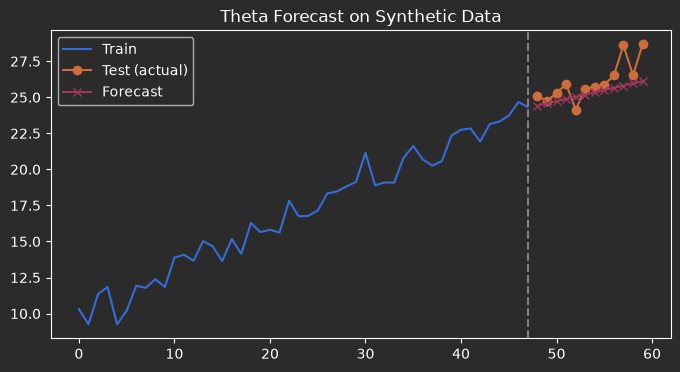

Test MSE over 12 steps: 1.539


In [2]:
# A series with curvature: accelerating (convex) growth + noise
rng = np.random.default_rng(7)
n_points = 60
time = np.arange(n_points)
y = 10 + 0.02 * time**2 + rng.normal(scale=0.8, size=n_points)

# Hold out the last 12 observations as a test set
y_train, y_test = y[:-12], y[-12:]

# Fit and forecast one step ahead with aeon Theta
forecaster = Theta(theta=2.0, weight=0.5)
forecaster.fit(y_train)
y_pred = forecaster.forecast(y_train)

# Forecast across the whole test horizon
y_preds = forecaster.iterative_forecast(y_train, prediction_horizon=len(y_test))

# Plot train, test actuals and the forecast together
test_time = np.arange(len(y_train), len(y))
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(y_train)), y_train, label="Train")
plt.plot(test_time, y_test, marker="o", label="Test (actual)")
plt.plot(test_time, y_preds, marker="x", label="Theta forecast")
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
plt.legend()
plt.title("Theta Forecast on a Curved Series")
plt.show()

mse = np.mean((y_test - y_preds) ** 2)
print(f"Test MSE over {len(y_test)} steps: {mse:.2f}")

The forecast is a **straight line**: a convex combination of the extrapolated linear trend and the flat SES level. This is the defining behaviour of classical Theta, and it is exactly right when the series has a constant linear trend.

Here, though, the series *curves* (the growth accelerates), so the straight-line forecast undershoots the test data and the error is relatively large. Classical Theta fixes its trend line once and cannot adapt to changing slope. You also cannot properly refit or update it without knowing the true future values, and it has no seasonal component, so it does poorly on seasonal data (see the airline example below).

These limitations motivate the **[Dynamic Optimised Theta Model (DOTM)](dotm.ipynb)**, which keeps Theta's decomposition idea but *re-estimates its trend line dynamically* as data arrives and optimises the theta parameter. On this very same series DOTM's forecast bends to follow the curve and roughly halves the test error.


### 6. Airline passengers

Of course we have to do the airline data to make a point.


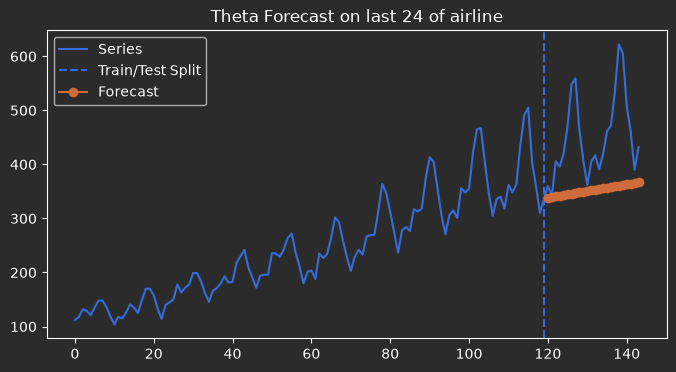

MSE on test set: 15085.202


In [3]:
y_air = load_airline().squeeze()
y_train, y_test = y_air[:-24], y_air[-24:]
# Plot
theta = Theta()
y_pred = theta.iterative_forecast(y_train, prediction_horizon=24)
time = np.arange(len(y_air))
plt.figure(figsize=(8, 4))
plt.plot(time, y_air, label="Series")
plt.axvline(x=len(y_train) - 1, linestyle="--", label="Train/Test Split")
plt.plot(np.arange(len(y_train), len(y_air)), y_pred, marker="o", label="Forecast")
plt.legend()
plt.title("Theta Forecast on last 24 of airline")
plt.show()

# MSE
mse = np.mean((y_test - y_pred) ** 2)
print(f"MSE on test set: {mse:.3f}")

Clearly, Theta is not appropriate for the airline data, which has a strong seasonal
component. There are many variants of the Theta model.

| Variant                 | Main change(s)                                                           | Forecasting engine                                     | Ref.  |
|-------------------------|---------------------------------------------------------------------------|--------------------------------------------------------|-------|
| Classic Theta           | Fixed θ = {0, 2}, equal weights                                           | Linear trend for θ=0; SES for θ=2                      | [1,2] |
| Optimised Theta (OTM)   | Choose θ and weights (via CV/IC)                                          | Same as classic per line; tuned combo                  | [3,4] |
| Dynamic OTM (DOTM)      | OTM + dynamic long-run line in state-space model                          | State-space recursions                                 | [3]   |
| Generalised Theta (GTM) | Vary line type (linear/non-linear), slope adj., additive or multiplicative recomposition | Depends on chosen line/extrapolator; automatic selection | [5]   |
| Structural Theta        | Formulated as structural state-space model                               | Kalman filter / MLE                                    | [6]   |

References
[1] V. Assimakopoulos & K. Nikolopoulos (2000). The Theta model: A decomposition approach to forecasting. International Journal of Forecasting, 16(4), 521–530.

[2] R.J. Hyndman & S. Billah (2003). Unmasking the Theta method. International Journal of Forecasting, 19(2), 287–290.

[3] J.A. Fiorucci, T.R. Pellegrini, F. Louzada, F. Petropoulos & A.B. Koehler (2016). Models for optimising the Theta method and their relationship to state space models. International Journal of Forecasting, 32(4), 1151–1161.

[4] J.A. Fiorucci et al. (2015). The Optimised Theta Method. arXiv preprint arXiv:1503.03529.

[5] E. Spiliotis, K. Nikolopoulos & V. Assimakopoulos (2020). Generalizing the Theta method for automatic forecasting. European Journal of Operational Research, 284(2), 550–558.

[6] G. Sbrana & A. Silvestrini (2025). The structural Theta method and its predictive performance in the M4-Competition. International Journal of Forecasting, 41(3), 940–952.